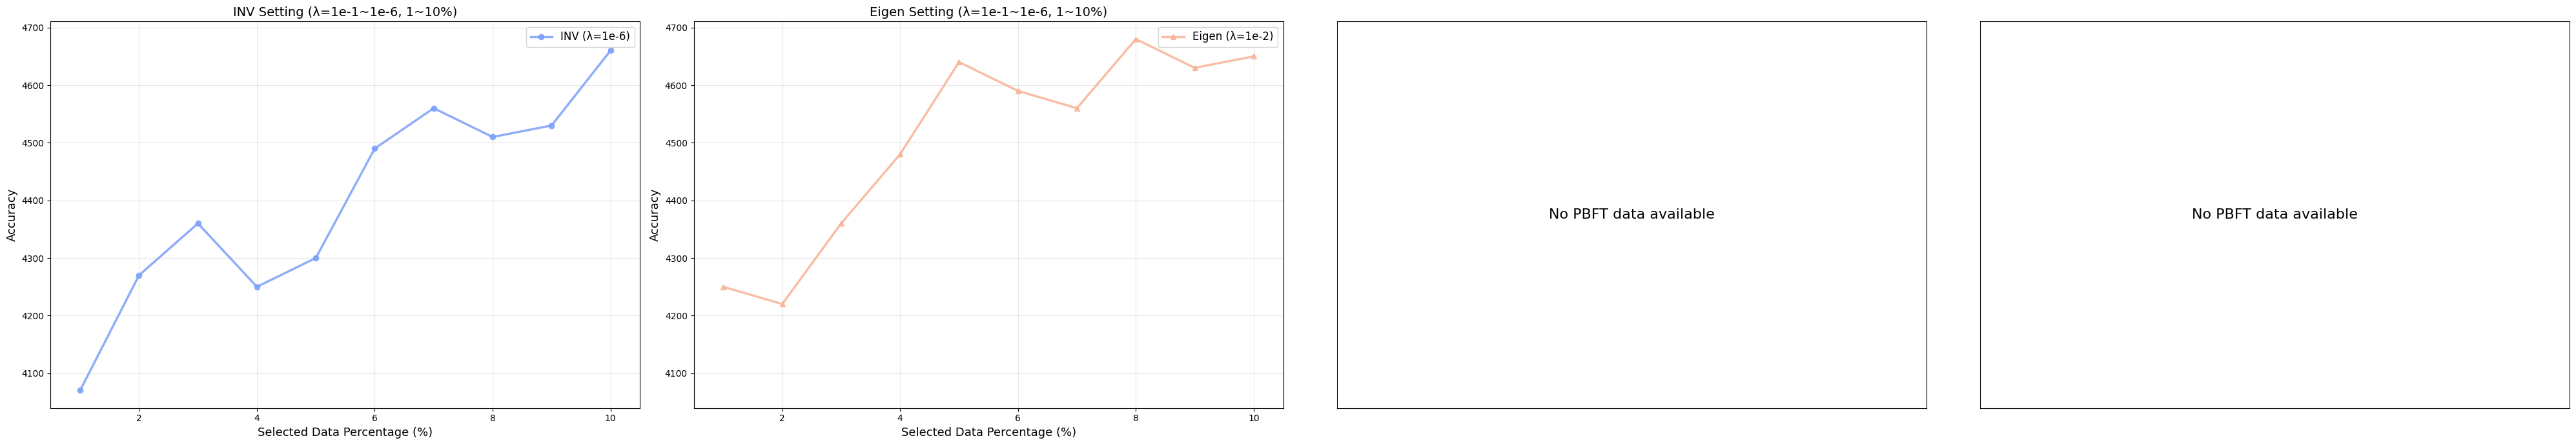

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 1000
rank = 10
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [4070, 4270, 4360, 4250, 4300, 4490, 4560, 4510, 4530, 4660, 4580, 4650, 4630, 4620, 4700, 4760, 4820, 4900, 4930, 4990, 4990, 4970, 5040, 4960, 4970, 5030, 5090, 5090, 5210, 5210, 5290, 5360, 5380, 5410, 5460, 5500, 5470, 5610, 5520, 5530, 5500, 5510, 5600, 5620, 5620, 5630, 5660, 5650, 5670, 5750, 5820, 5890, 5800, 5820, 5800, 5840, 5840, 5830, 5940, 5880, 5800, 5740, 5760, 5770, 5730, 5830, 5830, 5760, 5820, 5790, 5730, 5810, 5850, 5880, 5950, 5840, 5850, 5920, 5940, 5890, 5880, 5810, 5780, 5820, 5760, 5860, 5740, 5740, 5720, 5690, 5700, 5610, 5470, 5510, 5530, 5540, 5400, 5330, 5250, 5080] 
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [4250, 4220, 4360, 4480, 4640, 4590, 4560, 4680, 4630, 4650, 4720, 4680, 4720, 4720, 4910, 4940, 5110, 5080, 5060, 5120, 5130, 5150, 5100, 5200, 5280, 5250, 5210, 5300, 5240, 5190, 5220, 5330, 5300, 5330, 5320, 5260, 5260, 5250, 5220, 5250, 5260, 5280, 5260, 5290, 5350, 5400, 5440, 5420, 5410, 5410, 5410, 5380, 5470, 5490, 5520, 5470, 5510, 5480, 5480, 5490, 5500, 5440, 5420, 5420, 5410, 5460, 5450, 5450, 5490, 5440, 5420, 5460, 5400, 5370, 5420, 5380, 5410, 5450, 5460, 5490, 5460, 5530, 5480, 5490, 5440, 5500, 5560, 5480, 5430, 5430, 5410, 5420, 5390, 5370, 5360, 5260, 5290, 5290, 5210, 5130]
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [3690, 4310, 4540, 4420, 4030, 4090, 4050, 4160, 4230, 4260, 4290, 4050, 4190, 4270, 4300, 4330, 4420, 4370, 4480, 4580, 4610, 4540, 4650, 4460, 4430, 4330, 4600, 4510, 4370, 4470, 4540, 4660, 4650, 4760, 4650, 4640, 4680, 4710, 4770, 4690, 4700, 4700, 4780, 4750, 4700, 4770, 4800, 4700, 4710, 4750, 4820, 4770, 4820, 4720, 4800, 4780, 4840, 4840, 4820, 4910, 4890, 4920, 4870, 4890, 4940, 4950, 4900, 4900, 4820, 4860, 4920, 4880, 4880, 4950, 4880, 4870, 4900, 4850, 4860, 4980, 4950, 5020, 4950, 4950, 4920, 4910, 4870, 4850, 4780, 4820, 4850, 4840, 4900, 4900, 4920, 4900, 4930, 4930, 4950, 5080]
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [3670, 4220, 4340, 4510, 4110, 3870, 4010, 3930, 3910, 3990, 3960, 3780, 3860, 3790, 3810, 3800, 3830, 3890, 4130, 4100, 4220, 4140, 4170, 4270, 4250, 4270, 4340, 4400, 4360, 4310, 4300, 4350, 4260, 4360, 4350, 4420, 4410, 4560, 4570, 4660, 4700, 4770, 4740, 4770, 4710, 4680, 4680, 4630, 4740, 4760, 4760, 4810, 4900, 4860, 4840, 4900, 4890, 4940, 4950, 4970, 4800, 4870, 4930, 5040, 4920, 4880, 4880, 4890, 4900, 4970, 4940, 5040, 5000, 4980, 5030, 4980, 5000, 5010, 5100, 5040, 5080, 5110, 5070, 5090, 5070, 5100, 5060, 5030, 5010, 5010, 5030, 4990, 5020, 5040, 5100, 5080, 5040, 5150, 5110, 5130]
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

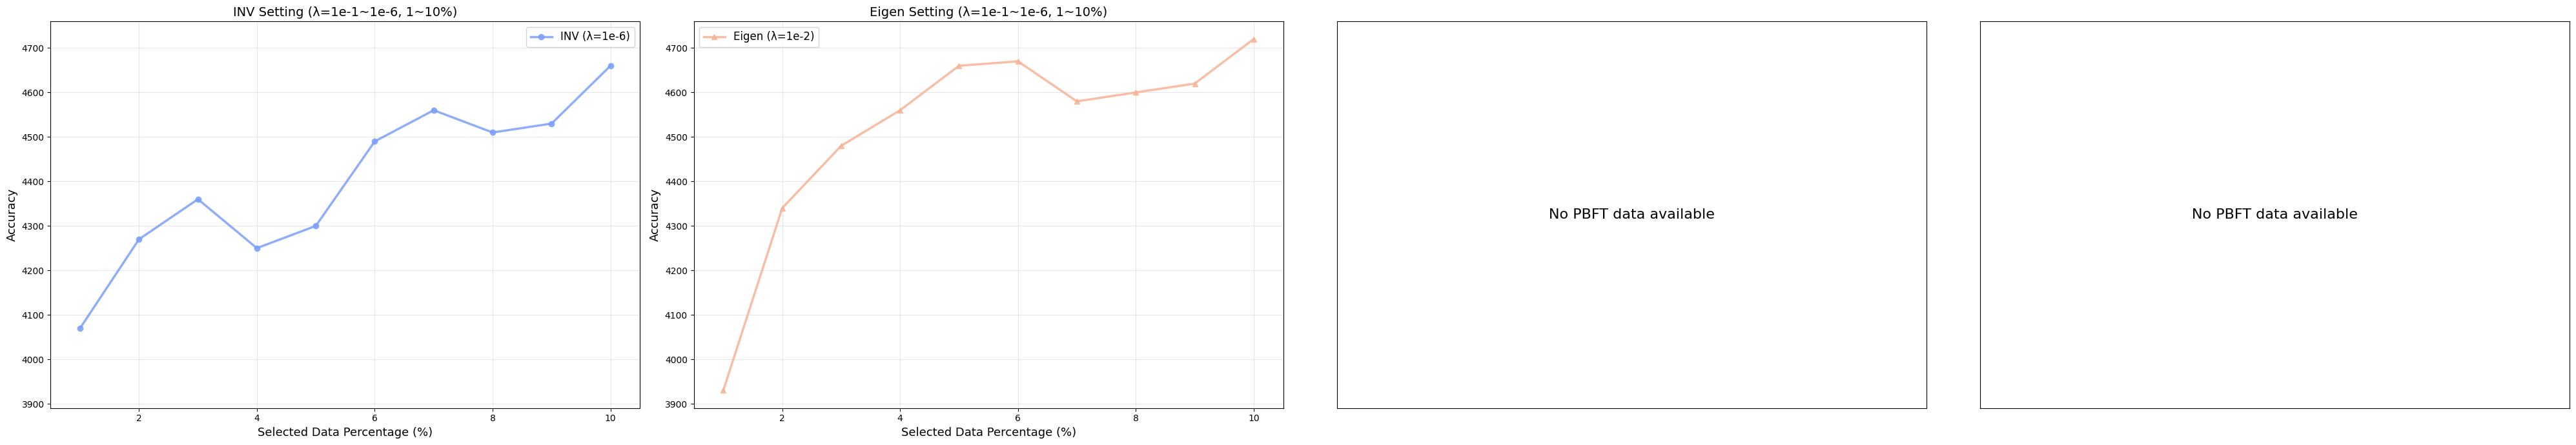

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 1000
rank = 20
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [4070, 4270, 4360, 4250, 4300, 4490, 4560, 4510, 4530, 4660, 4580, 4650, 4630, 4620, 4700, 4760, 4820, 4900, 4930, 4990, 4990, 4970, 5040, 4960, 4970, 5030, 5090, 5090, 5210, 5210, 5290, 5360, 5380, 5410, 5460, 5500, 5470, 5610, 5520, 5530, 5500, 5510, 5600, 5620, 5620, 5630, 5660, 5650, 5670, 5750, 5820, 5890, 5800, 5820, 5800, 5840, 5840, 5830, 5940, 5880, 5800, 5740, 5760, 5770, 5730, 5830, 5830, 5760, 5820, 5790, 5730, 5810, 5850, 5880, 5950, 5840, 5850, 5920, 5940, 5890, 5880, 5810, 5780, 5820, 5760, 5860, 5740, 5740, 5720, 5690, 5700, 5610, 5470, 5510, 5530, 5540, 5400, 5330, 5250, 5080] 
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [3930, 4340, 4480, 4560, 4660, 4670, 4580, 4600, 4620, 4720, 4790, 4780, 4770, 4740, 4870, 4960, 4980, 4970, 5020, 5070, 5030, 5070, 5080, 5040, 5040, 5200, 5220, 5240, 5250, 5280, 5380, 5520, 5400, 5440, 5420, 5500, 5490, 5590, 5490, 5560, 5540, 5540, 5500, 5510, 5480, 5630, 5680, 5690, 5760, 5730, 5620, 5680, 5810, 5760, 5730, 5620, 5670, 5650, 5670, 5670, 5630, 5600, 5660, 5580, 5590, 5550, 5620, 5620, 5480, 5530, 5590, 5540, 5510, 5530, 5480, 5450, 5490, 5480, 5500, 5460, 5470, 5410, 5470, 5490, 5480, 5470, 5450, 5420, 5390, 5460, 5380, 5350, 5340, 5320, 5250, 5190, 5180, 5180, 5140, 5100]
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [3690, 4310, 4540, 4420, 4030, 4090, 4050, 4160, 4230, 4260, 4290, 4050, 4190, 4270, 4300, 4330, 4420, 4370, 4480, 4580, 4610, 4540, 4650, 4460, 4430, 4330, 4600, 4510, 4370, 4470, 4540, 4660, 4650, 4760, 4650, 4640, 4680, 4710, 4770, 4690, 4700, 4700, 4780, 4750, 4700, 4770, 4800, 4700, 4710, 4750, 4820, 4770, 4820, 4720, 4800, 4780, 4840, 4840, 4820, 4910, 4890, 4920, 4870, 4890, 4940, 4950, 4900, 4900, 4820, 4860, 4920, 4880, 4880, 4950, 4880, 4870, 4900, 4850, 4860, 4980, 4950, 5020, 4950, 4950, 4920, 4910, 4870, 4850, 4780, 4820, 4850, 4840, 4900, 4900, 4920, 4900, 4930, 4930, 4950, 5080]
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [3630, 4120, 4380, 4410, 3890, 3850, 4000, 3910, 3940, 3880, 3780, 3670, 3820, 3670, 3780, 3800, 3880, 3950, 4020, 4020, 4030, 4160, 4120, 4200, 4150, 4210, 4120, 4100, 3980, 4050, 4060, 4020, 4030, 4230, 4170, 4210, 4150, 4150, 4310, 4260, 4460, 4300, 4440, 4390, 4470, 4440, 4420, 4460, 4470, 4520, 4550, 4570, 4570, 4490, 4470, 4460, 4510, 4530, 4480, 4620, 4650, 4590, 4680, 4660, 4740, 4660, 4820, 4820, 4850, 4810, 4780, 4880, 4830, 4830, 4800, 4840, 4810, 4920, 5020, 5050, 4990, 5020, 5090, 5060, 5050, 5120, 5010, 5030, 4960, 4980, 4970, 5020, 4980, 5050, 4950, 4980, 4980, 5070, 4970, 5100]
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

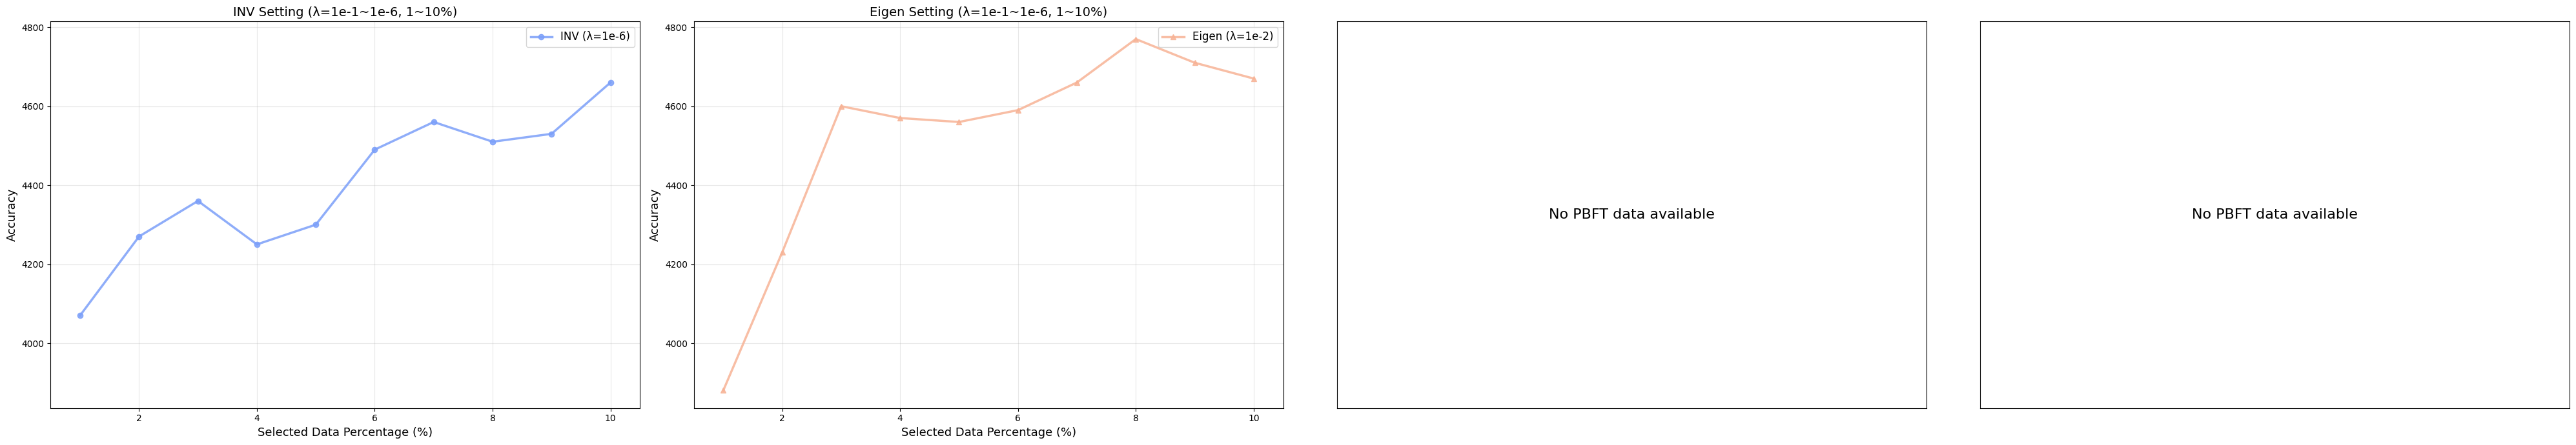

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 1000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [4070, 4270, 4360, 4250, 4300, 4490, 4560, 4510, 4530, 4660, 4580, 4650, 4630, 4620, 4700, 4760, 4820, 4900, 4930, 4990, 4990, 4970, 5040, 4960, 4970, 5030, 5090, 5090, 5210, 5210, 5290, 5360, 5380, 5410, 5460, 5500, 5470, 5610, 5520, 5530, 5500, 5510, 5600, 5620, 5620, 5630, 5660, 5650, 5670, 5750, 5820, 5890, 5800, 5820, 5800, 5840, 5840, 5830, 5940, 5880, 5800, 5740, 5760, 5770, 5730, 5830, 5830, 5760, 5820, 5790, 5730, 5810, 5850, 5880, 5950, 5840, 5850, 5920, 5940, 5890, 5880, 5810, 5780, 5820, 5760, 5860, 5740, 5740, 5720, 5690, 5700, 5610, 5470, 5510, 5530, 5540, 5400, 5330, 5250, 5080] 
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [3880, 4230, 4600, 4570, 4560, 4590, 4660, 4770, 4710, 4670, 4860, 4810, 4830, 4760, 4810, 4930, 4970, 5080, 4970, 4950, 5050, 5060, 5200, 5260, 5300, 5300, 5270, 5270, 5410, 5240, 5260, 5300, 5340, 5270, 5280, 5440, 5430, 5420, 5540, 5490, 5450, 5460, 5450, 5430, 5410, 5480, 5560, 5510, 5560, 5610, 5670, 5650, 5630, 5700, 5690, 5660, 5640, 5770, 5670, 5690, 5710, 5820, 5780, 5660, 5730, 5810, 5770, 5720, 5580, 5670, 5600, 5580, 5440, 5500, 5540, 5570, 5650, 5610, 5550, 5570, 5540, 5620, 5650, 5550, 5500, 5530, 5480, 5500, 5510, 5510, 5510, 5420, 5370, 5340, 5340, 5240, 5080, 5040, 5000, 5020] 
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [3690, 4310, 4540, 4420, 4030, 4090, 4050, 4160, 4230, 4260, 4290, 4050, 4190, 4270, 4300, 4330, 4420, 4370, 4480, 4580, 4610, 4540, 4650, 4460, 4430, 4330, 4600, 4510, 4370, 4470, 4540, 4660, 4650, 4760, 4650, 4640, 4680, 4710, 4770, 4690, 4700, 4700, 4780, 4750, 4700, 4770, 4800, 4700, 4710, 4750, 4820, 4770, 4820, 4720, 4800, 4780, 4840, 4840, 4820, 4910, 4890, 4920, 4870, 4890, 4940, 4950, 4900, 4900, 4820, 4860, 4920, 4880, 4880, 4950, 4880, 4870, 4900, 4850, 4860, 4980, 4950, 5020, 4950, 4950, 4920, 4910, 4870, 4850, 4780, 4820, 4850, 4840, 4900, 4900, 4920, 4900, 4930, 4930, 4950, 5080]
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [3690, 4130, 4440, 4400, 4010, 3890, 3940, 4090, 4070, 4180, 4130, 3980, 3930, 4040, 3890, 3940, 4130, 4270, 4240, 4190, 4240, 4120, 4240, 4190, 4070, 4180, 4230, 4120, 4110, 4080, 4110, 4020, 4120, 4180, 4170, 4210, 4320, 4350, 4380, 4300, 4340, 4370, 4310, 4380, 4530, 4380, 4440, 4420, 4370, 4320, 4340, 4290, 4270, 4350, 4350, 4400, 4280, 4380, 4430, 4410, 4500, 4490, 4450, 4510, 4500, 4480, 4510, 4630, 4660, 4640, 4590, 4590, 4610, 4650, 4560, 4590, 4520, 4600, 4890, 4780, 4720, 4740, 4860, 4870, 4880, 4970, 4940, 4850, 4950, 4870, 4970, 4990, 4970, 4970, 4950, 4970, 5000, 5050, 5050, 5020] 
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

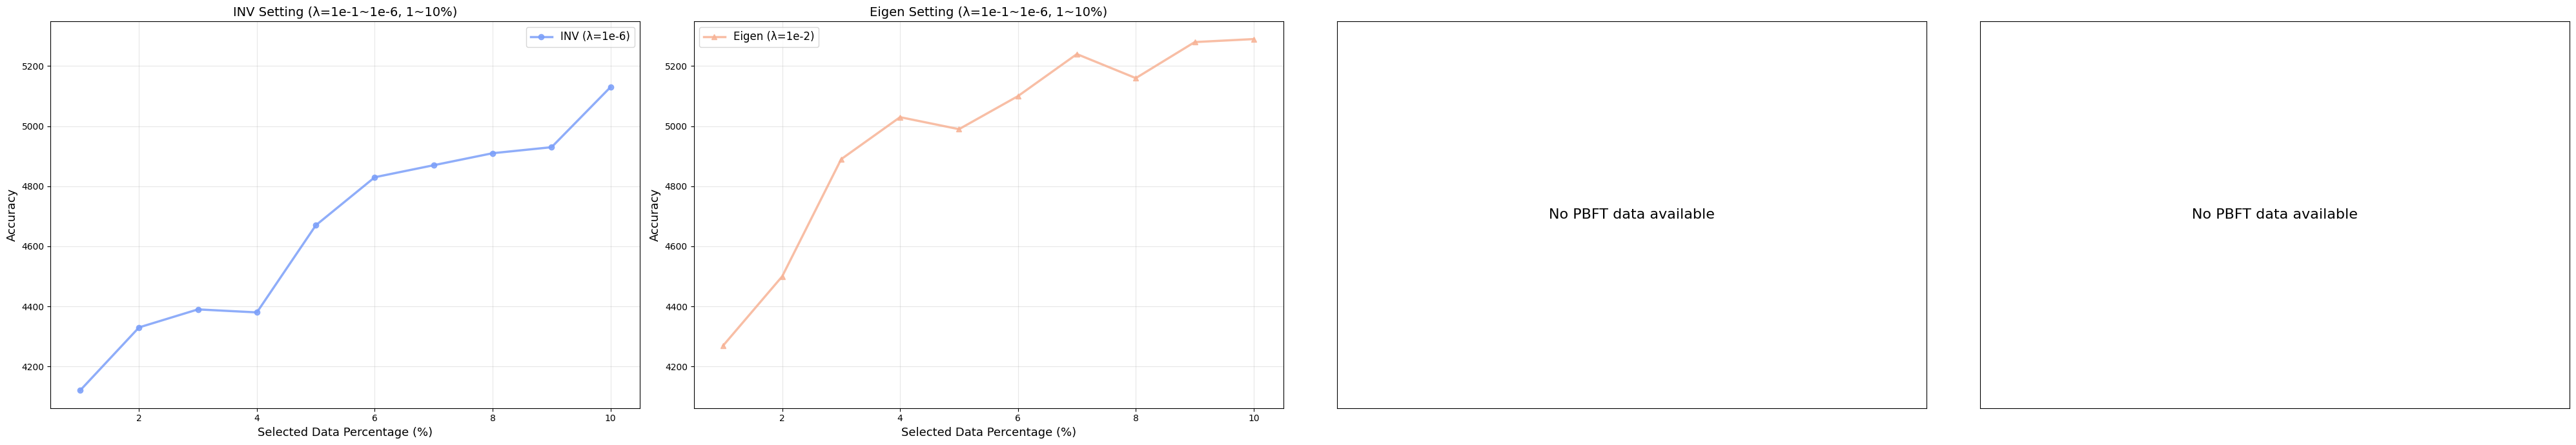

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
rank = 10
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [4120, 4330, 4390, 4380, 4670, 4830, 4870, 4910, 4930, 5130, 5140, 5260, 5240, 5220, 5330, 5390, 5390, 5410, 5490, 5470, 5490, 5500, 5530, 5540, 5630, 5720, 5720, 5690, 5670, 5710, 5730, 5730, 5800, 5800, 5800, 5790, 5840, 5900, 5840, 5940, 5970, 5950, 6020, 6060, 6130, 6110, 6170, 6130, 6130, 6220, 6230, 6280, 6310, 6340, 6380, 6370, 6360, 6400, 6420, 6440, 6420, 6460, 6400, 6430, 6390, 6370, 6330, 6400, 6450, 6480, 6460, 6450, 6550, 6470, 6390, 6380, 6380, 6360, 6330, 6380, 6280, 6340, 6310, 6300, 6290, 6290, 6250, 6180, 6130, 6140, 6060, 6020, 5990, 5890, 5790, 5730, 5620, 5590, 5420, 5220]  
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [4270, 4500, 4890, 5030, 4990, 5100, 5240, 5160, 5280, 5290, 5250, 5280, 5310, 5320, 5280, 5360, 5430, 5480, 5430, 5520, 5580, 5520, 5520, 5500, 5550, 5620, 5620, 5730, 5720, 5720, 5700, 5790, 5690, 5670, 5660, 5670, 5700, 5680, 5680, 5750, 5750, 5780, 5710, 5710, 5750, 5820, 5830, 5740, 5700, 5640, 5630, 5740, 5730, 5770, 5730, 5740, 5830, 5790, 5830, 5790, 5850, 5830, 5890, 5840, 5920, 5980, 5960, 5920, 5930, 5950, 5930, 5940, 5960, 5980, 5980, 5880, 5880, 5840, 5840, 5870, 5900, 5900, 5850, 5840, 5770, 5720, 5690, 5700, 5690, 5640, 5620, 5610, 5660, 5620, 5510, 5450, 5400, 5450, 5410, 5250] 
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [4270, 4240, 4510, 4500, 4320, 4490, 4460, 4500, 4490, 4500, 4450, 4590, 4800, 4740, 4700, 4780, 4850, 4940, 4870, 4960, 4810, 4900, 4910, 4970, 4820, 4850, 4970, 4920, 4930, 4820, 4890, 4800, 4950, 4890, 5000, 4900, 4950, 4990, 4940, 4930, 4980, 4960, 5050, 5000, 5040, 5150, 5170, 5060, 5170, 5120, 5140, 5210, 5280, 5280, 5250, 5250, 5240, 5230, 5130, 5090, 5120, 5090, 5080, 5140, 5160, 5150, 5150, 5150, 5020, 5060, 5050, 5150, 5070, 5110, 5140, 5140, 5210, 5200, 5300, 5280, 5290, 5310, 5260, 5360, 5340, 5280, 5240, 5310, 5330, 5330, 5330, 5340, 5180, 5150, 5210, 5330, 5340, 5290, 5230, 5220]
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [4210, 4120, 4380, 4040, 4230, 4290, 4430, 4050, 3980, 3950, 3820, 3990, 4000, 4180, 4070, 4320, 4280, 4250, 4250, 4320, 4520, 4470, 4420, 4350, 4320, 4420, 4400, 4310, 4440, 4540, 4630, 4560, 4510, 4530, 4670, 4570, 4670, 4690, 4630, 4720, 4800, 4760, 4680, 4730, 4750, 4730, 4790, 4730, 4760, 4820, 4960, 5000, 5040, 5000, 5020, 4940, 5010, 5010, 5000, 5080, 5090, 5070, 5060, 5040, 4950, 5050, 5050, 4990, 5000, 4990, 5030, 4990, 5000, 4980, 5000, 4970, 4990, 4990, 4920, 4960, 4950, 5010, 5000, 5180, 5140, 5110, 5080, 5100, 5330, 5250, 5260, 5260, 5240, 5270, 5230, 5260, 5230, 5240, 5200, 5250]      
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

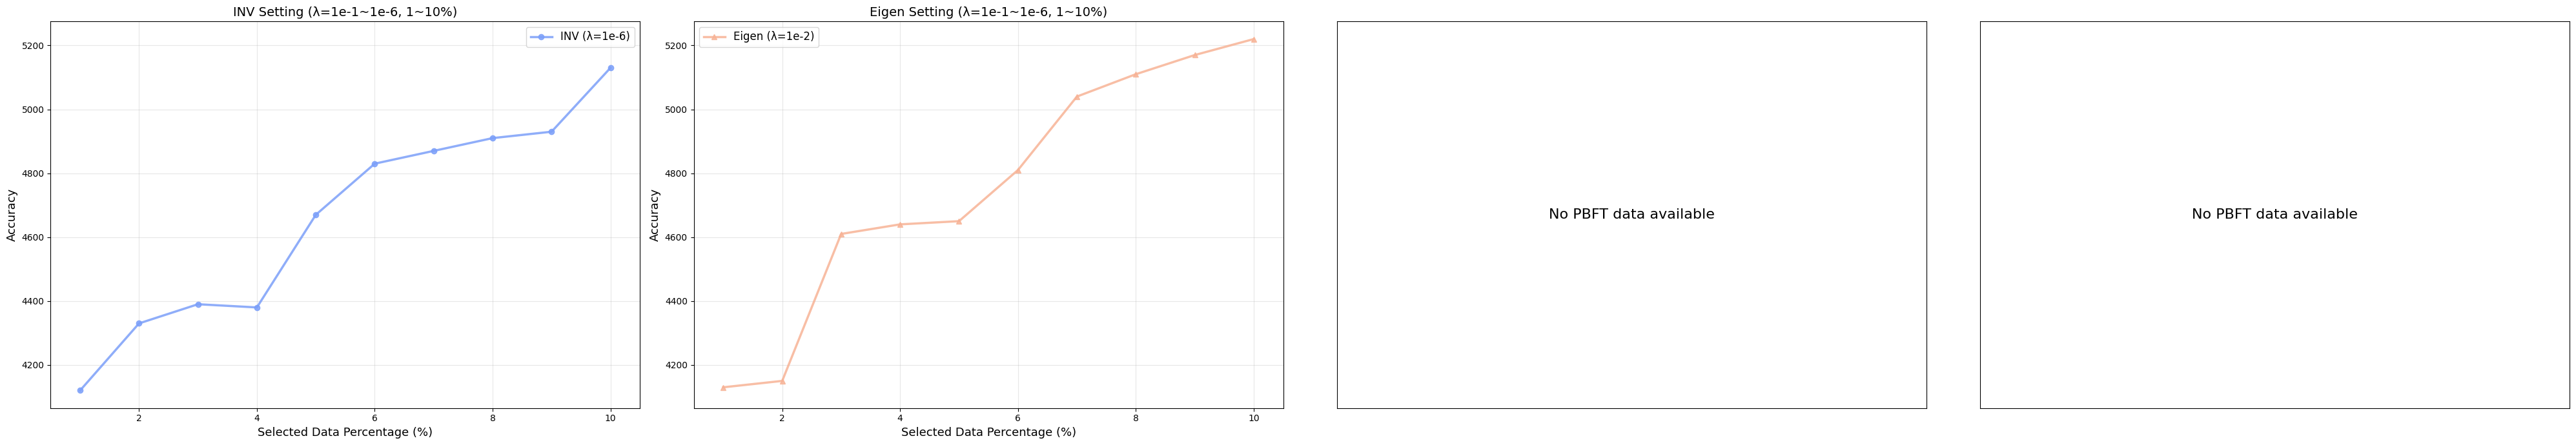

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
rank = 20
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [4120, 4330, 4390, 4380, 4670, 4830, 4870, 4910, 4930, 5130, 5140, 5260, 5240, 5220, 5330, 5390, 5390, 5410, 5490, 5470, 5490, 5500, 5530, 5540, 5630, 5720, 5720, 5690, 5670, 5710, 5730, 5730, 5800, 5800, 5800, 5790, 5840, 5900, 5840, 5940, 5970, 5950, 6020, 6060, 6130, 6110, 6170, 6130, 6130, 6220, 6230, 6280, 6310, 6340, 6380, 6370, 6360, 6400, 6420, 6440, 6420, 6460, 6400, 6430, 6390, 6370, 6330, 6400, 6450, 6480, 6460, 6450, 6550, 6470, 6390, 6380, 6380, 6360, 6330, 6380, 6280, 6340, 6310, 6300, 6290, 6290, 6250, 6180, 6130, 6140, 6060, 6020, 5990, 5890, 5790, 5730, 5620, 5590, 5420, 5220]  
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [4130, 4150, 4610, 4640, 4650, 4810, 5040, 5110, 5170, 5220, 5300, 5280, 5360, 5370, 5380, 5400, 5420, 5360, 5460, 5540, 5540, 5600, 5630, 5650, 5680, 5660, 5810, 5810, 5750, 5800, 5880, 5980, 5850, 5860, 5860, 5900, 5880, 6020, 6120, 6070, 6000, 5950, 6020, 5990, 6000, 5990, 6040, 6090, 6170, 6130, 6080, 6130, 6100, 6050, 6070, 6070, 6110, 6020, 5940, 5980, 6030, 6030, 6030, 6050, 6080, 6090, 5970, 5950, 6020, 5970, 5990, 5960, 5980, 5980, 6010, 5990, 5990, 5960, 6020, 6000, 5950, 5860, 5820, 5820, 5860, 5780, 5830, 5780, 5770, 5720, 5670, 5670, 5660, 5500, 5500, 5470, 5470, 5360, 5320, 5190] 
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [4270, 4240, 4510, 4500, 4320, 4490, 4460, 4500, 4490, 4500, 4450, 4590, 4800, 4740, 4700, 4780, 4850, 4940, 4870, 4960, 4810, 4900, 4910, 4970, 4820, 4850, 4970, 4920, 4930, 4820, 4890, 4800, 4950, 4890, 5000, 4900, 4950, 4990, 4940, 4930, 4980, 4960, 5050, 5000, 5040, 5150, 5170, 5060, 5170, 5120, 5140, 5210, 5280, 5280, 5250, 5250, 5240, 5230, 5130, 5090, 5120, 5090, 5080, 5140, 5160, 5150, 5150, 5150, 5020, 5060, 5050, 5150, 5070, 5110, 5140, 5140, 5210, 5200, 5300, 5280, 5290, 5310, 5260, 5360, 5340, 5280, 5240, 5310, 5330, 5330, 5330, 5340, 5180, 5150, 5210, 5330, 5340, 5290, 5230, 5220]
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [4300, 4200, 4380, 4220, 4280, 4430, 4380, 4160, 4280, 4150, 3950, 4170, 4080, 4220, 4180, 4020, 4140, 4150, 4200, 4330, 4220, 4360, 4290, 4340, 4380, 4420, 4450, 4490, 4630, 4630, 4560, 4580, 4620, 4500, 4610, 4570, 4550, 4640, 4590, 4570, 4590, 4540, 4610, 4670, 4650, 4640, 4760, 4660, 4670, 4800, 4690, 4780, 4880, 4840, 4820, 4970, 4980, 4970, 4950, 4960, 4940, 4880, 4910, 4990, 4960, 4980, 5000, 4930, 4970, 4950, 4920, 4990, 5030, 5050, 5090, 5020, 4950, 5030, 5080, 5110, 5000, 5140, 5170, 5220, 5160, 5130, 5170, 5150, 5170, 5150, 5220, 5220, 5100, 5120, 5170, 5100, 5080, 5080, 5120, 5190] 
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

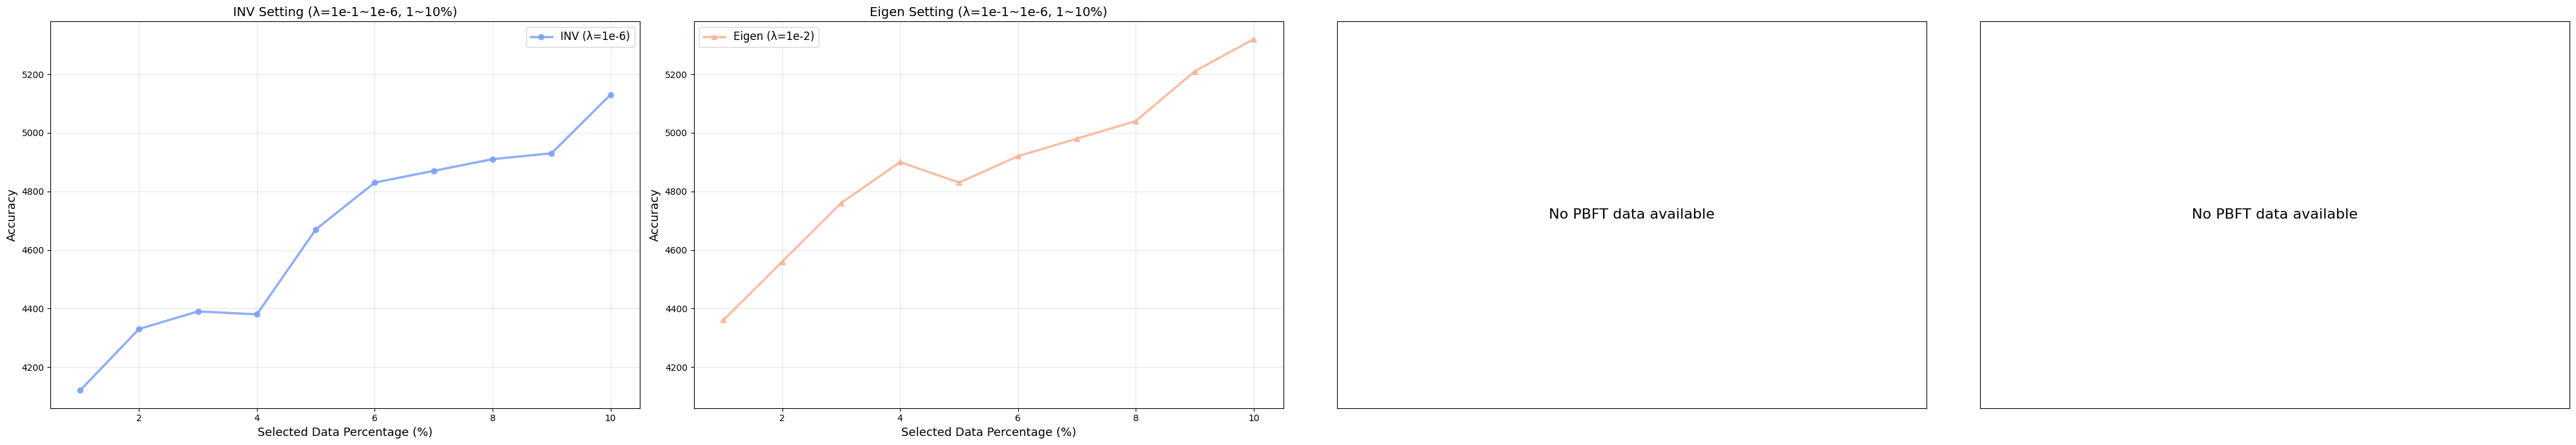

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [4120, 4330, 4390, 4380, 4670, 4830, 4870, 4910, 4930, 5130, 5140, 5260, 5240, 5220, 5330, 5390, 5390, 5410, 5490, 5470, 5490, 5500, 5530, 5540, 5630, 5720, 5720, 5690, 5670, 5710, 5730, 5730, 5800, 5800, 5800, 5790, 5840, 5900, 5840, 5940, 5970, 5950, 6020, 6060, 6130, 6110, 6170, 6130, 6130, 6220, 6230, 6280, 6310, 6340, 6380, 6370, 6360, 6400, 6420, 6440, 6420, 6460, 6400, 6430, 6390, 6370, 6330, 6400, 6450, 6480, 6460, 6450, 6550, 6470, 6390, 6380, 6380, 6360, 6330, 6380, 6280, 6340, 6310, 6300, 6290, 6290, 6250, 6180, 6130, 6140, 6060, 6020, 5990, 5890, 5790, 5730, 5620, 5590, 5420, 5220]  
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [4360, 4560, 4760, 4900, 4830, 4920, 4980, 5040, 5210, 5320, 5500, 5470, 5420, 5470, 5510, 5560, 5520, 5510, 5630, 5520, 5650, 5700, 5730, 5710, 5790, 5750, 5810, 5860, 5840, 5830, 5820, 5840, 5910, 5960, 5970, 6060, 6040, 6080, 6010, 6040, 5960, 5930, 6020, 5970, 5990, 6010, 5960, 5900, 5940, 6050, 6120, 6110, 6070, 6140, 6150, 6170, 6110, 6140, 6160, 6150, 6210, 6260, 6310, 6300, 6330, 6290, 6280, 6330, 6280, 6250, 6200, 6260, 6230, 6200, 6190, 6250, 6240, 6150, 6220, 6180, 6200, 6160, 6100, 6050, 6080, 6070, 6140, 6080, 6110, 6080, 6070, 6030, 5940, 5990, 5930, 5840, 5790, 5680, 5630, 5490] 
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [4270, 4240, 4510, 4500, 4320, 4490, 4460, 4500, 4490, 4500, 4450, 4590, 4800, 4740, 4700, 4780, 4850, 4940, 4870, 4960, 4810, 4900, 4910, 4970, 4820, 4850, 4970, 4920, 4930, 4820, 4890, 4800, 4950, 4890, 5000, 4900, 4950, 4990, 4940, 4930, 4980, 4960, 5050, 5000, 5040, 5150, 5170, 5060, 5170, 5120, 5140, 5210, 5280, 5280, 5250, 5250, 5240, 5230, 5130, 5090, 5120, 5090, 5080, 5140, 5160, 5150, 5150, 5150, 5020, 5060, 5050, 5150, 5070, 5110, 5140, 5140, 5210, 5200, 5300, 5280, 5290, 5310, 5260, 5360, 5340, 5280, 5240, 5310, 5330, 5330, 5330, 5340, 5180, 5150, 5210, 5330, 5340, 5290, 5230, 5220]
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [4310, 4120, 4370, 4270, 4370, 4490, 4570, 4310, 4350, 4450, 4140, 4330, 4440, 4380, 4290, 4330, 4330, 4480, 4490, 4520, 4380, 4630, 4550, 4490, 4500, 4500, 4710, 4560, 4480, 4470, 4670, 4650, 4770, 4740, 4700, 4700, 4660, 4630, 4650, 4580, 4610, 4740, 4710, 4730, 4710, 4650, 4810, 4660, 4670, 4830, 4800, 4900, 4890, 4880, 4790, 4810, 4870, 4940, 4980, 4980, 5040, 5000, 5090, 5050, 5030, 5000, 4990, 5040, 4960, 4930, 4880, 5010, 4940, 4900, 4960, 4980, 4970, 5040, 5020, 5090, 5170, 5240, 5170, 5260, 5320, 5280, 5300, 5260, 5330, 5280, 5350, 5420, 5340, 5480, 5430, 5500, 5460, 5500, 5560, 5490]
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

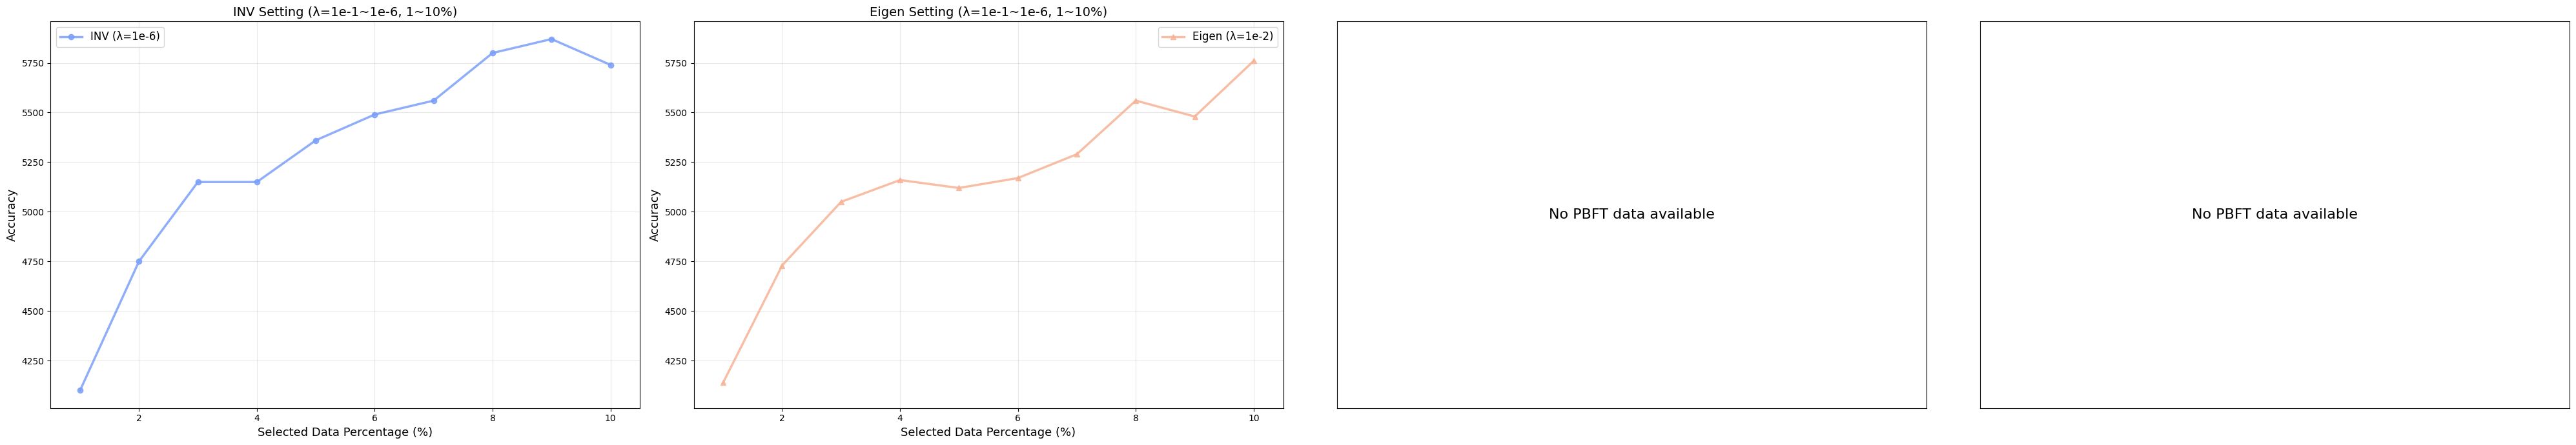

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 5000
rank = 10
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [4100, 4750, 5150, 5150, 5360, 5490, 5560, 5800, 5870, 5740, 5840, 5950, 5990, 5980, 6000, 6040, 6100, 6250, 6250, 6310, 6220, 6310, 6350, 6440, 6540, 6570, 6690, 6680, 6700, 6720, 6750, 6750, 6810, 6870, 6860, 6940, 7010, 6990, 7060, 7150, 7050, 7090, 7120, 7120, 7090, 7130, 7160, 7190, 7170, 7250, 7200, 7170, 7150, 7200, 7240, 7200, 7180, 7160, 7150, 7180, 7240, 7260, 7170, 7140, 7160, 7170, 7170, 7240, 7250, 7180, 7260, 7180, 7190, 7230, 7210, 7140, 7090, 7140, 7220, 7140, 7120, 7120, 7130, 7040, 7030, 6950, 6890, 6820, 6770, 6680, 6710, 6650, 6650, 6600, 6430, 6340, 6180, 6040, 5880, 5690] 
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [4130, 4690, 5150, 5210, 5110, 5130, 5310, 5520, 5510, 5800, 5820, 5780, 5790, 5880, 5980, 6090, 5970, 6110, 6210, 6190, 6240, 6250, 6250, 6310, 6350, 6320, 6360, 6340, 6340, 6230, 6380, 6460, 6460, 6490, 6430, 6380, 6410, 6460, 6510, 6490, 6410, 6460, 6420, 6360, 6390, 6490, 6540, 6550, 6520, 6530, 6550, 6540, 6570, 6570, 6520, 6470, 6390, 6400, 6410, 6420, 6450, 6400, 6400, 6390, 6430, 6460, 6480, 6340, 6410, 6360, 6400, 6340, 6340, 6380, 6380, 6380, 6310, 6330, 6300, 6250, 6250, 6220, 6190, 6180, 6200, 6150, 6070, 6090, 6040, 6050, 6020, 5920, 5920, 5880, 5820, 5810, 5670, 5600, 5410, 5340] 
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [4270, 4480, 4540, 4690, 4780, 4610, 4710, 4590, 4620, 4700, 4700, 4800, 4800, 4740, 4840, 4910, 4930, 4820, 4850, 4930, 4960, 5000, 5040, 5050, 5250, 5270, 5150, 5180, 5210, 5230, 5210, 5320, 5300, 5260, 5180, 5240, 5200, 5190, 5280, 5230, 5290, 5350, 5330, 5340, 5370, 5350, 5250, 5310, 5310, 5330, 5380, 5360, 5360, 5360, 5330, 5370, 5450, 5480, 5430, 5420, 5310, 5330, 5460, 5460, 5440, 5520, 5520, 5560, 5640, 5700, 5640, 5610, 5630, 5580, 5640, 5610, 5630, 5630, 5610, 5550, 5590, 5660, 5700, 5690, 5690, 5610, 5630, 5590, 5550, 5480, 5630, 5640, 5660, 5560, 5590, 5540, 5600, 5670, 5690, 5690] 
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [4170, 4140, 4360, 4370, 4540, 4190, 4210, 4160, 4440, 4300, 4220, 4470, 4550, 4620, 4680, 4780, 4740, 4550, 4500, 4670, 4840, 4800, 4830, 4960, 5050, 5110, 4960, 5110, 5100, 5150, 5120, 5190, 5090, 5130, 5120, 5170, 5200, 5180, 5160, 5210, 5290, 5300, 5210, 5180, 5270, 5170, 5170, 5270, 5200, 5200, 5180, 5180, 5220, 5230, 5200, 5250, 5210, 5220, 5150, 5110, 5160, 5200, 5190, 5130, 5050, 5090, 5160, 5110, 5120, 5090, 5130, 5120, 5110, 5030, 5100, 5130, 5210, 5250, 5170, 5150, 5180, 5270, 5290, 5280, 5330, 5270, 5280, 5370, 5420, 5350, 5380, 5360, 5300, 5320, 5380, 5420, 5380, 5360, 5380, 5340]   
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

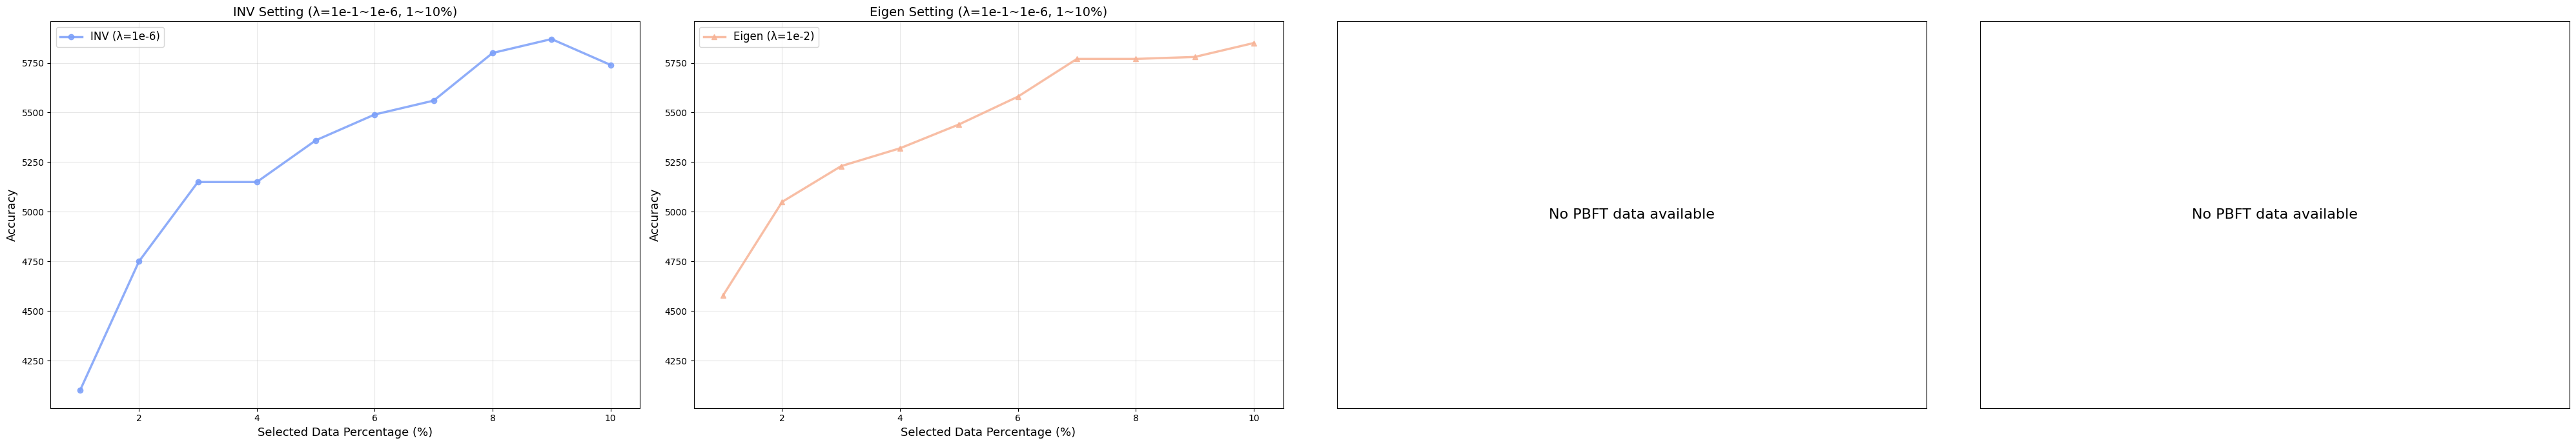

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 5000
rank = 20
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [4100, 4750, 5150, 5150, 5360, 5490, 5560, 5800, 5870, 5740, 5840, 5950, 5990, 5980, 6000, 6040, 6100, 6250, 6250, 6310, 6220, 6310, 6350, 6440, 6540, 6570, 6690, 6680, 6700, 6720, 6750, 6750, 6810, 6870, 6860, 6940, 7010, 6990, 7060, 7150, 7050, 7090, 7120, 7120, 7090, 7130, 7160, 7190, 7170, 7250, 7200, 7170, 7150, 7200, 7240, 7200, 7180, 7160, 7150, 7180, 7240, 7260, 7170, 7140, 7160, 7170, 7170, 7240, 7250, 7180, 7260, 7180, 7190, 7230, 7210, 7140, 7090, 7140, 7220, 7140, 7120, 7120, 7130, 7040, 7030, 6950, 6890, 6820, 6770, 6680, 6710, 6650, 6650, 6600, 6430, 6340, 6180, 6040, 5880, 5690] 
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [4570, 5040, 5190, 5370, 5440, 5610, 5810, 5740, 5790, 5820, 5930, 5930, 5960, 6050, 5970, 5970, 5990, 5980, 6010, 6260, 6270, 6240, 6230, 6310, 6270, 6270, 6340, 6450, 6410, 6420, 6460, 6460, 6410, 6440, 6530, 6490, 6570, 6720, 6650, 6630, 6540, 6590, 6640, 6630, 6620, 6670, 6640, 6620, 6700, 6790, 6900, 6920, 6830, 6810, 6790, 6850, 6900, 6790, 6860, 6890, 6870, 6890, 6890, 6900, 6870, 6850, 6840, 6890, 6840, 6870, 6900, 6840, 6840, 6850, 6720, 6740, 6610, 6640, 6650, 6560, 6660, 6620, 6650, 6570, 6500, 6490, 6440, 6470, 6360, 6320, 6270, 6180, 6140, 6150, 6100, 6040, 5900, 5830, 5610, 5470]   
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [4270, 4480, 4540, 4690, 4780, 4610, 4710, 4590, 4620, 4700, 4700, 4800, 4800, 4740, 4840, 4910, 4930, 4820, 4850, 4930, 4960, 5000, 5040, 5050, 5250, 5270, 5150, 5180, 5210, 5230, 5210, 5320, 5300, 5260, 5180, 5240, 5200, 5190, 5280, 5230, 5290, 5350, 5330, 5340, 5370, 5350, 5250, 5310, 5310, 5330, 5380, 5360, 5360, 5360, 5330, 5370, 5450, 5480, 5430, 5420, 5310, 5330, 5460, 5460, 5440, 5520, 5520, 5560, 5640, 5700, 5640, 5610, 5630, 5580, 5640, 5610, 5630, 5630, 5610, 5550, 5590, 5660, 5700, 5690, 5690, 5610, 5630, 5590, 5550, 5480, 5630, 5640, 5660, 5560, 5590, 5540, 5600, 5670, 5690, 5690] 
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [4160, 4260, 4470, 4540, 4750, 4410, 4270, 4350, 4430, 4570, 4570, 4530, 4530, 4380, 4310, 4390, 4370, 4310, 4350, 4250, 4530, 4620, 4650, 4650, 4750, 4830, 4740, 4900, 4950, 5050, 5100, 5130, 4980, 4940, 4990, 4980, 4920, 4910, 4980, 5020, 5080, 5230, 5130, 5300, 5270, 5240, 5250, 5170, 5140, 5260, 5250, 5220, 5300, 5280, 5330, 5320, 5390, 5400, 5390, 5370, 5270, 5330, 5330, 5340, 5280, 5290, 5310, 5250, 5340, 5330, 5260, 5320, 5330, 5410, 5440, 5400, 5360, 5430, 5420, 5420, 5400, 5440, 5520, 5530, 5470, 5470, 5480, 5540, 5540, 5470, 5510, 5440, 5470, 5490, 5490, 5480, 5470, 5580, 5550, 5470]      
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 -> red, 1e-6 -> blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1~1e-6, 1~10%) =====
ax_left = axes[0]
ax_middle = axes[1]

plot_percent = selected_dp_percent[:10]

inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'INV (λ={lam_label})', alpha=0.85
        )

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(
            plot_percent, data[:10],
            color=lambda_colors[i], linewidth=2.5, linestyle='-',
            marker=marker, markersize=6,
            label=f'Eigen (λ={lam_label})', alpha=0.85
        )

shared_series = [
    d[:10] for d, _, _ in (inv_lambda_configs + eigen_lambda_configs) if d is not None
]
if shared_series:
    y_min = min(min(series) for series in shared_series)
    y_max = max(max(series) for series in shared_series)
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

ax_left.set_xlim(0.5, 10.5)
ax_middle.set_xlim(0.5, 10.5)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title('INV Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_left.legend(fontsize=12, loc='best')
ax_left.grid(True, alpha=0.3)

# ===== Subplot (1,2): Eigen setting (λ=1e-1~1e-6, 1~10%) =====
ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title('Eigen Setting (λ=1e-1~1e-6, 1~10%)', fontsize=14)
ax_middle.legend(fontsize=12, loc='best')
ax_middle.grid(True, alpha=0.3)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()

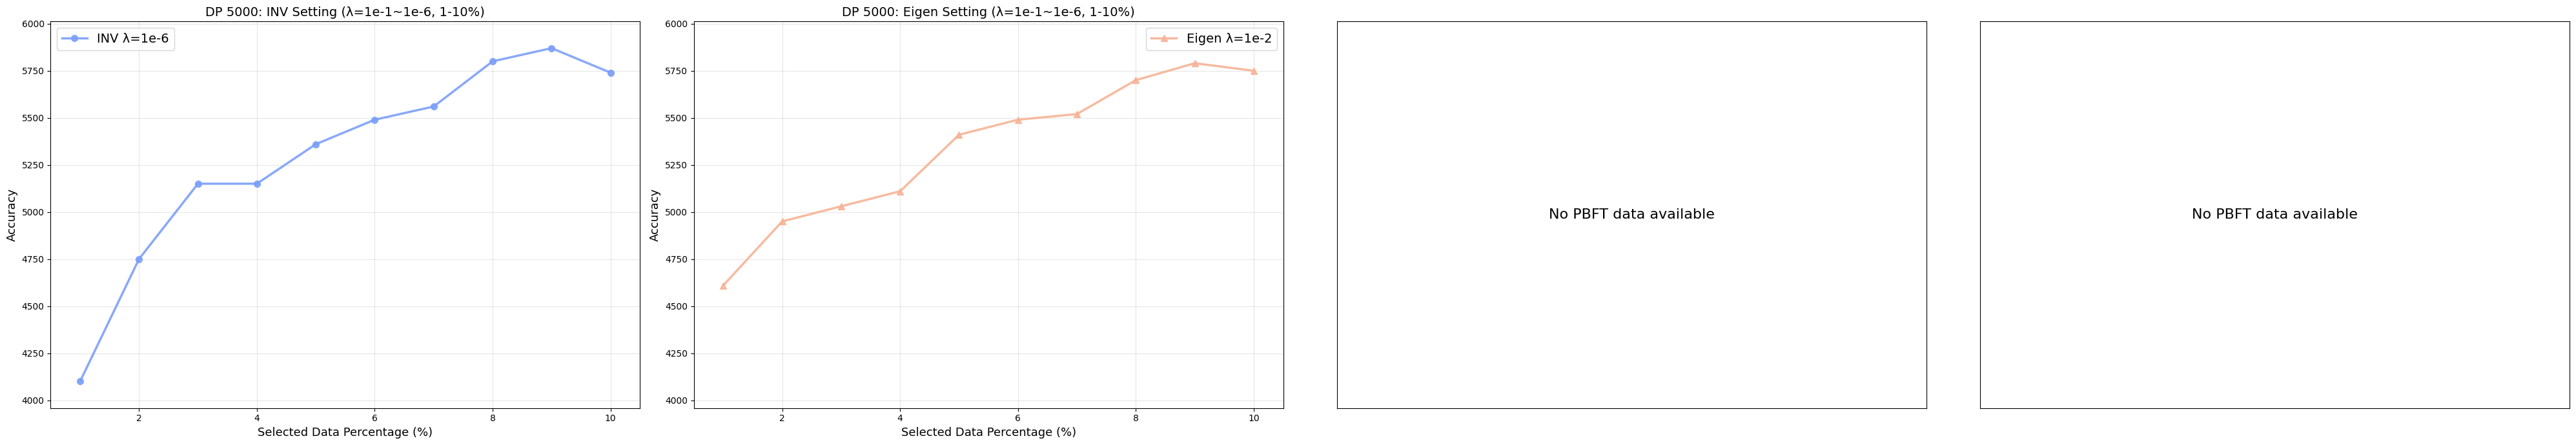

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 5000
rank = 30
iteration = 500
# =========================

def ema_smooth(data, alpha=0.2):
    """Apply Exponential Moving Average smoothing."""
    ema = [data[0]]
    for i in range(1, len(data)):
        ema.append(alpha * data[i] + (1 - alpha) * ema[-1])
    return ema

selected_dp_percent = [i for i in range(1, 101)]

# Prediction with top shapley values
inv_lam1e_6      = [4100, 4750, 5150, 5150, 5360, 5490, 5560, 5800, 5870, 5740, 5840, 5950, 5990, 5980, 6000, 6040, 6100, 6250, 6250, 6310, 6220, 6310, 6350, 6440, 6540, 6570, 6690, 6680, 6700, 6720, 6750, 6750, 6810, 6870, 6860, 6940, 7010, 6990, 7060, 7150, 7050, 7090, 7120, 7120, 7090, 7130, 7160, 7190, 7170, 7250, 7200, 7170, 7150, 7200, 7240, 7200, 7180, 7160, 7150, 7180, 7240, 7260, 7170, 7140, 7160, 7170, 7170, 7240, 7250, 7180, 7260, 7180, 7190, 7230, 7210, 7140, 7090, 7140, 7220, 7140, 7120, 7120, 7130, 7040, 7030, 6950, 6890, 6820, 6770, 6680, 6710, 6650, 6650, 6600, 6430, 6340, 6180, 6040, 5880, 5690] 
inv_lam1e_5      = None
inv_lam1e_4      = None
inv_lam1e_3      = None
inv_lam1e_2      = None
inv_lam1e_1      = None
eigen_lam1e_6    = None
eigen_lam1e_5    = None
eigen_lam1e_4    = None
eigen_lam1e_3    = None
eigen_lam1e_2    = [4610, 4950, 5030, 5110, 5410, 5490, 5520, 5700, 5790, 5750, 5840, 6010, 6020, 6020, 6100, 6170, 6220, 6240, 6300, 6350, 6330, 6410, 6440, 6470, 6420, 6410, 6380, 6550, 6490, 6460, 6520, 6570, 6470, 6620, 6680, 6640, 6650, 6700, 6670, 6580, 6660, 6710, 6700, 6800, 6930, 6900, 6790, 6870, 6830, 6830, 6850, 6950, 6950, 6890, 7070, 6960, 7000, 6980, 6960, 6910, 7010, 6960, 7000, 7000, 6950, 6950, 6990, 7000, 7000, 6980, 7010, 6980, 6980, 6870, 6850, 6860, 6850, 6880, 6680, 6800, 6760, 6770, 6760, 6680, 6630, 6660, 6600, 6470, 6440, 6430, 6350, 6250, 6170, 6140, 6080, 6000, 5910, 5780, 5640, 5520] 
eigen_lam1e_1    = None

# Prediction with random shapley values
r_inv_lam1e_6     = [4270, 4480, 4540, 4690, 4780, 4610, 4710, 4590, 4620, 4700, 4700, 4800, 4800, 4740, 4840, 4910, 4930, 4820, 4850, 4930, 4960, 5000, 5040, 5050, 5250, 5270, 5150, 5180, 5210, 5230, 5210, 5320, 5300, 5260, 5180, 5240, 5200, 5190, 5280, 5230, 5290, 5350, 5330, 5340, 5370, 5350, 5250, 5310, 5310, 5330, 5380, 5360, 5360, 5360, 5330, 5370, 5450, 5480, 5430, 5420, 5310, 5330, 5460, 5460, 5440, 5520, 5520, 5560, 5640, 5700, 5640, 5610, 5630, 5580, 5640, 5610, 5630, 5630, 5610, 5550, 5590, 5660, 5700, 5690, 5690, 5610, 5630, 5590, 5550, 5480, 5630, 5640, 5660, 5560, 5590, 5540, 5600, 5670, 5690, 5690] 
r_inv_lam1e_5     = None
r_inv_lam1e_4     = None
r_inv_lam1e_3     = None
r_inv_lam1e_2     = None
r_inv_lam1e_1     = None
r_eigen_lam1e_6   = None
r_eigen_lam1e_5   = None
r_eigen_lam1e_4   = None
r_eigen_lam1e_3   = None
r_eigen_lam1e_2   = [4220, 4300, 4470, 4620, 4690, 4440, 4410, 4310, 4340, 4470, 4510, 4580, 4510, 4430, 4420, 4460, 4410, 4470, 4520, 4500, 4580, 4490, 4460, 4610, 4560, 4680, 4540, 4730, 4880, 5010, 4980, 5030, 4980, 4950, 5040, 5000, 4960, 4800, 4860, 4870, 4900, 5000, 4950, 4890, 5000, 5060, 5150, 5080, 5130, 5090, 5090, 5220, 5140, 5200, 5160, 5170, 5200, 5260, 5350, 5350, 5290, 5320, 5210, 5240, 5270, 5110, 5280, 5270, 5240, 5270, 5290, 5400, 5410, 5400, 5400, 5460, 5430, 5490, 5520, 5580, 5540, 5570, 5520, 5600, 5500, 5490, 5530, 5510, 5590, 5510, 5510, 5570, 5470, 5470, 5470, 5480, 5540, 5510, 5560, 5520]  
r_eigen_lam1e_1   = None

# PBFT
selected_dp_percent_prompt_based_ft = [i for i in range(1, 101)]
pbft_inv           = None
pbft_eigen_lam1e_2 = None

# Filter out None values and prepare lambda configs
lambda_configs_orig = []
lambda_configs_ema = []
lambda_configs_random_ema = []

# Add available data for original
if eigen_lam1e_6 is not None:
    lambda_configs_orig.append((eigen_lam1e_6, '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_orig.append((eigen_lam1e_5, '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_orig.append((eigen_lam1e_4, '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_orig.append((eigen_lam1e_3, '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_orig.append((eigen_lam1e_2, '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_orig.append((eigen_lam1e_1, '1e-1', '<'))

# Apply EMA smoothing for top shapley values
alpha = 0.2  # smoothing factor (0.1-0.3 typically works well)
inv_ema = ema_smooth(inv_lam1e_6, alpha) if inv_lam1e_6 else None

# Add available data for EMA
if eigen_lam1e_6 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_6, alpha), '1e-6', 'o'))
if eigen_lam1e_5 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_5, alpha), '1e-5', 's'))
if eigen_lam1e_4 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_4, alpha), '1e-4', 'D'))
if eigen_lam1e_3 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_3, alpha), '1e-3', 'v'))
if eigen_lam1e_2 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_2, alpha), '1e-2', '^'))
if eigen_lam1e_1 is not None:
    lambda_configs_ema.append((ema_smooth(eigen_lam1e_1, alpha), '1e-1', '<'))

# Apply EMA smoothing for random shapley values
r_inv_ema = ema_smooth(r_inv_lam1e_6, alpha) if r_inv_lam1e_6 else None

# Add available data for random EMA
if r_eigen_lam1e_6 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_6, alpha), '1e-6', 'o'))
if r_eigen_lam1e_5 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_5, alpha), '1e-5', 's'))
if r_eigen_lam1e_4 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_4, alpha), '1e-4', 'D'))
if r_eigen_lam1e_3 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_3, alpha), '1e-3', 'v'))
if r_eigen_lam1e_2 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_2, alpha), '1e-2', '^'))
if r_eigen_lam1e_1 is not None:
    lambda_configs_random_ema.append((ema_smooth(r_eigen_lam1e_1, alpha), '1e-1', '<'))

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, 6))
lambda_colors = colors[::-1]  # 1e-1 red -> 1e-6 blue

# Color settings for consistency
inv_color = '#C9A227'
eigen_1e2_color = colors[4] if len(colors) > 4 else colors[-1]  # Lambda 1e-2 color

# Create figure with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(40, 7))

# ===== Subplot (1,1): INV setting (λ=1e-1 to 1e-6, 1-10%) =====
ax_left = axes[0]

plot_percent = selected_dp_percent[:10]
inv_lambda_configs = [
    (inv_lam1e_1, '1e-1', '<'),
    (inv_lam1e_2, '1e-2', '^'),
    (inv_lam1e_3, '1e-3', 'v'),
    (inv_lam1e_4, '1e-4', 'D'),
    (inv_lam1e_5, '1e-5', 's'),
    (inv_lam1e_6, '1e-6', 'o'),
]

eigen_lambda_configs = [
    (eigen_lam1e_1, '1e-1', '<'),
    (eigen_lam1e_2, '1e-2', '^'),
    (eigen_lam1e_3, '1e-3', 'v'),
    (eigen_lam1e_4, '1e-4', 'D'),
    (eigen_lam1e_5, '1e-5', 's'),
    (eigen_lam1e_6, '1e-6', 'o'),
]

# Shared y-axis range for (1,1) and (1,2)
shared_series = []
for data, _, _ in inv_lambda_configs + eigen_lambda_configs:
    if data is not None:
        shared_series.extend(data[:10])

if shared_series:
    y_min, y_max = min(shared_series), max(shared_series)
    y_pad = max(20, (y_max - y_min) * 0.08)
else:
    y_min, y_max, y_pad = 0, 1, 0

for i, (data, lam_label, marker) in enumerate(inv_lambda_configs):
    if data is not None:
        ax_left.plot(plot_percent, data[:10],
                     color=lambda_colors[i], linewidth=2.5, linestyle='-',
                     marker=marker, markersize=7,
                     label=f'INV λ={lam_label}', alpha=0.9)

ax_left.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_left.set_ylabel('Accuracy', fontsize=13)
ax_left.set_title(f'DP {num_dp}: INV Setting (λ=1e-1~1e-6, 1-10%)', fontsize=14)
ax_left.legend(fontsize=14, loc='best')
ax_left.grid(True, alpha=0.3)
ax_left.set_xlim(0.5, 10.5)
if shared_series:
    ax_left.set_ylim(y_min - y_pad, y_max + y_pad)

# ===== Subplot (1,2): Eigen setting (λ=1e-1 to 1e-6, 1-10%) =====
ax_middle = axes[1]

for i, (data, lam_label, marker) in enumerate(eigen_lambda_configs):
    if data is not None:
        ax_middle.plot(plot_percent, data[:10],
                       color=lambda_colors[i], linewidth=2.5, linestyle='-',
                       marker=marker, markersize=7,
                       label=f'Eigen λ={lam_label}', alpha=0.9)

ax_middle.set_xlabel('Selected Data Percentage (%)', fontsize=13)
ax_middle.set_ylabel('Accuracy', fontsize=13)
ax_middle.set_title(f'DP {num_dp}: Eigen Setting (λ=1e-1~1e-6, 1-10%)', fontsize=14)
ax_middle.legend(fontsize=14, loc='best')
ax_middle.grid(True, alpha=0.3)
ax_middle.set_xlim(0.5, 10.5)
if shared_series:
    ax_middle.set_ylim(y_min - y_pad, y_max + y_pad)

# ===== Subplot (1,3): Prompt-Based Fine-Tuning vs ENTK =====
ax_pbft = axes[2]

# Check if PBFT data is available
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Use all 100 data points for ENTK (1% to 100%)
    entk_selected_percent = selected_dp_percent
    entk_inv_values = inv_lam1e_6
    entk_eigen_1e2_values = eigen_lam1e_2

    # Plot INV: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_inv_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_inv_values, 
                 color=inv_color, linewidth=2.0, linestyle='-', 
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_pbft.plot(selected_dp_percent, pbft_inv, 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 label='INV PBFT', alpha=0.9)

    # Plot Eigen λ=1e-2: ENTK (solid, no marker) and PBFT (dashed, no marker)
    if entk_eigen_1e2_values is not None:
        ax_pbft.plot(entk_selected_percent, entk_eigen_1e2_values, 
                 color=eigen_1e2_color, linewidth=2.0, linestyle='-', 
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_pbft.plot(selected_dp_percent, pbft_eigen_lam1e_2, 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)

    ax_pbft.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_pbft.set_ylabel('Accuracy', fontsize=13)
    ax_pbft.set_title(f'DP {num_dp}: Prompt-Based Fine-Tuning vs ENTK', fontsize=14)
    ax_pbft.legend(fontsize=12, loc='best')
    ax_pbft.grid(True, alpha=0.3)
else:
    # Hide subplot if no PBFT data
    ax_pbft.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_pbft.transAxes)
    ax_pbft.set_xticks([])
    ax_pbft.set_yticks([])
    ax_pbft.grid(False)

# ===== Subplot (1,4): PBFT vs ENTK (1-10% Zoom) =====
ax_zoom = axes[3]

# Check if PBFT data is available for zoom plot
if pbft_inv is not None or pbft_eigen_lam1e_2 is not None:
    # Extract first 10 data points (1% to 10%)
    zoom_percent = selected_dp_percent[:10]
    
    # Plot INV: ENTK (solid) and PBFT (dashed) for 1-10%
    if inv_lam1e_6 is not None:
        ax_zoom.plot(zoom_percent, inv_lam1e_6[:10], 
                 color=inv_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'INV ENTK (iter={iteration})', alpha=0.9)
    if pbft_inv is not None:
        ax_zoom.plot(zoom_percent, pbft_inv[:10], 
                 color=inv_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='INV PBFT', alpha=0.9)
    
    # Plot Eigen λ=1e-2: ENTK (solid) and PBFT (dashed) for 1-10%
    if eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='-', 
                 marker='o', markersize=6,
                 label=f'Eigen λ=1e-2 ENTK (iter={iteration})', alpha=0.9)
    if pbft_eigen_lam1e_2 is not None:
        ax_zoom.plot(zoom_percent, pbft_eigen_lam1e_2[:10], 
                 color=eigen_1e2_color, linewidth=2.5, linestyle='--', 
                 marker='s', markersize=6,
                 label='Eigen λ=1e-2 PBFT', alpha=0.9)
    
    ax_zoom.set_xlabel('Selected Data Percentage (%)', fontsize=13)
    ax_zoom.set_ylabel('Accuracy', fontsize=13)
    ax_zoom.set_title(f'DP {num_dp}: PBFT vs ENTK (1-10% Zoom)', fontsize=14)
    ax_zoom.legend(fontsize=12, loc='best')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.set_xlim(0.5, 10.5)  # Focus on 1-10%
else:
    # Hide subplot if no PBFT data
    ax_zoom.text(0.5, 0.5, 'No PBFT data available', 
                 ha='center', va='center', fontsize=16, 
                 transform=ax_zoom.transAxes)
    ax_zoom.set_xticks([])
    ax_zoom.set_yticks([])
    ax_zoom.grid(False)

plt.tight_layout()
plt.show()